# Red convolucional sobre MNIST · Tema 2 · Sesión 3

**Máster en Ingeniería de Automatización con IA Agéntica · EBIS**
Autor: Manuel Díaz Bendito

Construimos una **CNN base** sobre MNIST y la dejamos preparada para **experimentar**: cambiar el número de filtros, añadir capas, ajustar el batch size o las épocas. Es el notebook con el que entender, parámetro a parámetro, cómo se comporta una red convolucional. En el siguiente notebook partimos de aquí para llegar a un modelo afinado.

## 0 · Compatibilidad de hardware (léeme primero)

Este notebook funciona en **cualquier ordenador**. El código detecta automáticamente el mejor dispositivo de cómputo disponible y se adapta a él:

- **CUDA** → GPU NVIDIA (Windows / Linux). El más rápido para entrenar.
- **MPS** → GPUs de Apple Silicon (M1/M2/M3/M4). Acelera mucho en Mac.
- **CPU** → cualquier máquina. Funciona siempre; más lento, pero perfectamente válido para los modelos de este notebook.

No tienes que cambiar nada manualmente: la celda de detección de dispositivo elige sola. Si entrenas en CPU, los tiempos de este notebook siguen siendo de pocos minutos.

## 1 · Importación de librerías

In [ ]:
# %pip install torch torchvision numpy matplotlib scikit-learn

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

torch.manual_seed(42); np.random.seed(42)
print("PyTorch:", torch.__version__)

PyTorch: 2.12.0


## 2 · Detección automática de dispositivo

In [2]:
def elegir_dispositivo():
    """Devuelve el mejor dispositivo disponible: CUDA > MPS > CPU."""
    if torch.cuda.is_available():
        print(f"✅ Usando CUDA (GPU NVIDIA): {torch.cuda.get_device_name(0)}")
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        print("✅ Usando MPS (Apple Silicon)")
        return torch.device("mps")
    print("⚠️  No se ha detectado GPU. Usando CPU (funciona igual, algo más lento).")
    return torch.device("cpu")

device = elegir_dispositivo()
print("Dispositivo seleccionado:", device)

✅ Usando MPS (Apple Silicon)
Dispositivo seleccionado: mps


## 3 · Carga y formato de datos

Separamos el conjunto de entrenamiento en **train** y **validación**. La validación nos permite vigilar el **sobreajuste**: si el accuracy de train sube pero el de validación se estanca o baja, la red está memorizando en lugar de generalizar.

In [3]:
transform = transforms.ToTensor()
full_train = datasets.MNIST(root="./datos", train=True,  download=True, transform=transform)
test_ds    = datasets.MNIST(root="./datos", train=False, download=True, transform=transform)

# 90 % train / 10 % validación
n_val = len(full_train) // 10
n_tr  = len(full_train) - n_val
train_ds, val_ds = random_split(full_train, [n_tr, n_val],
                                generator=torch.Generator().manual_seed(42))

# === PARÁMETROS PARA EXPERIMENTAR ===
batch_size = 64     # prueba 32, 64, 128...
num_epocas = 5      # sube a 10 para exprimir más

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)
print(f"Train: {n_tr} | Val: {n_val} | Test: {len(test_ds)}")

Train: 54000 | Val: 6000 | Test: 10000


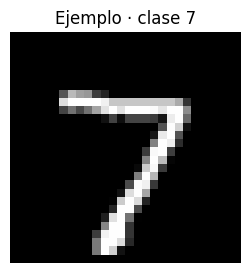

In [4]:
k = 0
img, lab = test_ds[k]
plt.figure(figsize=(3,3)); plt.imshow(img.squeeze().numpy(), cmap="gray")
plt.title(f"Ejemplo · clase {lab}"); plt.axis("off"); plt.show()

## 4 · Definimos la CNN base

Un único bloque convolucional seguido de clasificador denso. Es deliberadamente simple: el objetivo es que sea fácil de modificar.

`Conv(16) → ReLU → MaxPool → Flatten → Linear(10)`

In [5]:
class CNNBase(nn.Module):
    def __init__(self, n_filtros=16, n_clases=10):
        super().__init__()
        # EXPERIMENTA: añade más capas Conv2d/MaxPool, cambia n_filtros, prueba Dropout...
        self.conv = nn.Conv2d(1, n_filtros, kernel_size=3, padding=1)  # (n_filtros,28,28)
        self.pool = nn.MaxPool2d(2, 2)                                 # (n_filtros,14,14)
        self.fc   = nn.Linear(n_filtros * 14 * 14, n_clases)
    def forward(self, x):
        x = self.pool(F.relu(self.conv(x)))
        x = torch.flatten(x, 1)
        return self.fc(x)

modelo = CNNBase().to(device)
print(modelo)
print("Parámetros:", sum(p.numel() for p in modelo.parameters()))

CNNBase(
  (conv): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=3136, out_features=10, bias=True)
)
Parámetros: 31530


## 5 · Entrenamiento con seguimiento de validación

Guardamos los pesos del **mejor modelo** según el accuracy de validación (equivalente al `ModelCheckpoint` que usábamos en Keras).

In [6]:
import os
os.makedirs("./pesos", exist_ok=True)
RUTA_PESOS = "./pesos/cnn_base_mnist.pt"

def evaluar(modelo, loader):
    modelo.eval(); correctos = total = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            correctos += (modelo(x).argmax(1) == y).sum().item(); total += y.size(0)
    return correctos / total

criterio = nn.CrossEntropyLoss()
optimizador = torch.optim.Adam(modelo.parameters(), lr=1e-3)

hist = {"train_loss": [], "val_acc": []}
mejor_val = 0.0
for epoca in range(num_epocas):
    modelo.train(); perdida = 0.0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        loss = criterio(modelo(x), y)
        optimizador.zero_grad(); loss.backward(); optimizador.step()
        perdida += loss.item()
    val_acc = evaluar(modelo, val_loader)
    hist["train_loss"].append(perdida/len(train_loader)); hist["val_acc"].append(val_acc)
    if val_acc > mejor_val:
        mejor_val = val_acc
        torch.save(modelo.state_dict(), RUTA_PESOS)   # guarda el mejor
    print(f"Época {epoca+1}/{num_epocas} | loss {hist['train_loss'][-1]:.4f} | val acc {val_acc*100:.2f} %")
print(f"\nMejor accuracy de validación: {mejor_val*100:.2f} % (pesos guardados en {RUTA_PESOS})")

Época 1/5 | loss 0.3653 | val acc 94.37 %
Época 2/5 | loss 0.1422 | val acc 96.40 %
Época 3/5 | loss 0.0952 | val acc 97.27 %
Época 4/5 | loss 0.0742 | val acc 97.50 %
Época 5/5 | loss 0.0624 | val acc 97.78 %

Mejor accuracy de validación: 97.78 % (pesos guardados en ./pesos/cnn_base_mnist.pt)


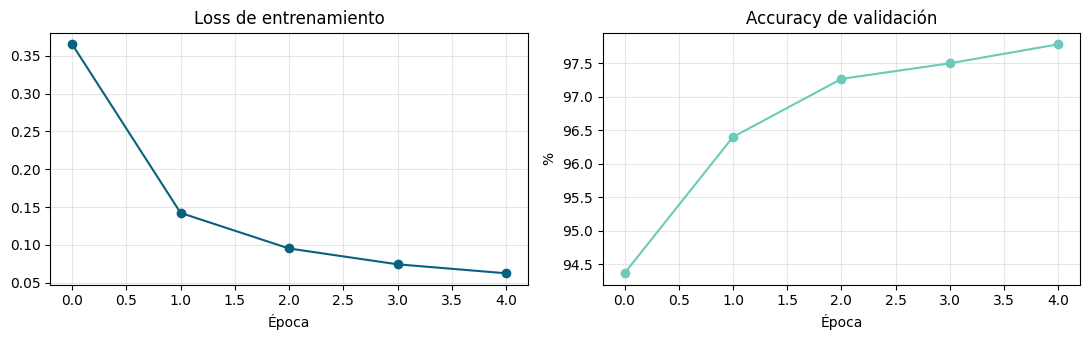

In [7]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.5))
a1.plot(hist["train_loss"], marker="o", color="#08627F"); a1.set_title("Loss de entrenamiento"); a1.set_xlabel("Época"); a1.grid(alpha=0.3)
a2.plot([v*100 for v in hist["val_acc"]], marker="o", color="#6ACBB8"); a2.set_title("Accuracy de validación"); a2.set_xlabel("Época"); a2.set_ylabel("%"); a2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 6 · Evaluación en el conjunto de test

Cargamos los **mejores pesos** y medimos sobre datos que el modelo no ha visto nunca.

In [8]:
modelo.load_state_dict(torch.load(RUTA_PESOS, map_location=device))
print(f"Accuracy en test: {evaluar(modelo, test_loader)*100:.2f} %")

Accuracy en test: 98.00 %


## 7 · Para experimentar

Ideas concretas para mejorar este modelo (y motivación del siguiente notebook):

- Añade un **segundo bloque** `Conv + ReLU + MaxPool` con más filtros (32).
- Inserta **BatchNorm** tras cada convolución para entrenar más rápido y estable.
- Añade **Dropout** antes de la capa densa para reducir el sobreajuste.
- Prueba más **épocas** y distintos **batch sizes**.

En el notebook *"...mejorada"* aplicamos todas estas ideas a la vez y comparamos resultados.